# Drug Response Classification – SVM
**0 = No Response | 1 = Positive Response**

In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 10\Pharma_Industry.csv")
print(df.shape)
display(df.head())


(500, 6)


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


## 1. EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None
Missing: 0 | Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
Drug Dosage (mg),500.0,-0.037761,0.979891,-3.019512,-0.642003,-0.019340,0.641151,2.949094
Systolic Blood Pressure (mmHg),500.0,0.214957,1.247567,-3.773897,-0.565168,0.201532,0.951375,4.111751
Heart Rate (BPM),500.0,0.062871,0.971978,-2.940389,-0.648157,0.027732,0.710774,3.193108
Liver Toxicity Index (U/L),500.0,0.054398,0.986001,-3.401277,-0.586085,-0.065661,0.633914,3.373269
Blood Glucose Level (mg/dL),500.0,-0.171863,0.983765,-3.110431,-0.797715,-0.108106,0.513555,2.518023
Drug Response,500.0,0.520000,0.500100,0.000000,0.000000,1.000000,1.000000,1.000000


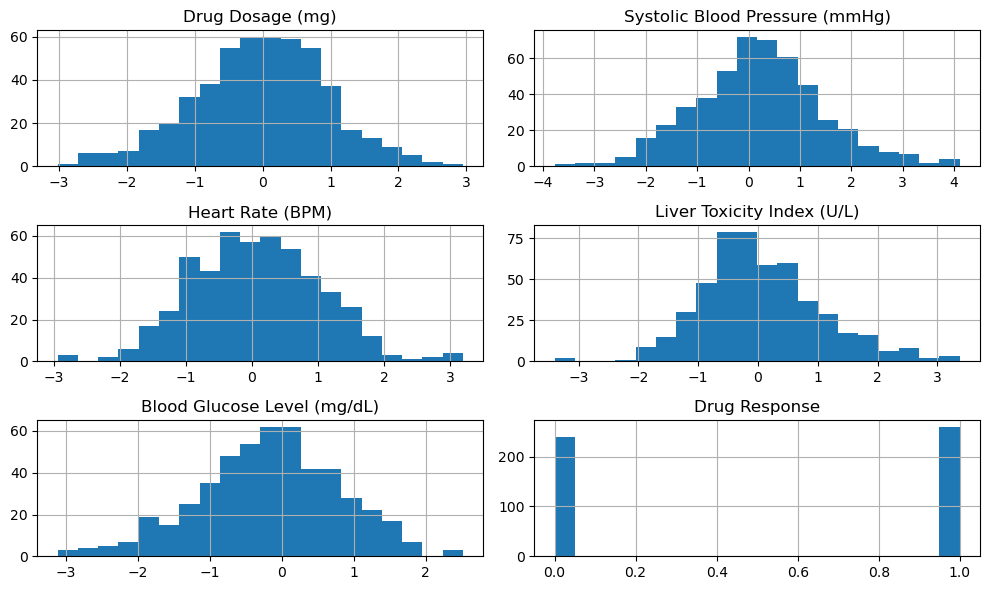

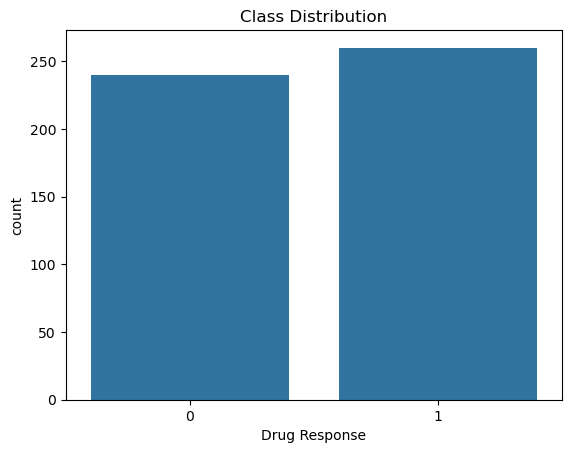

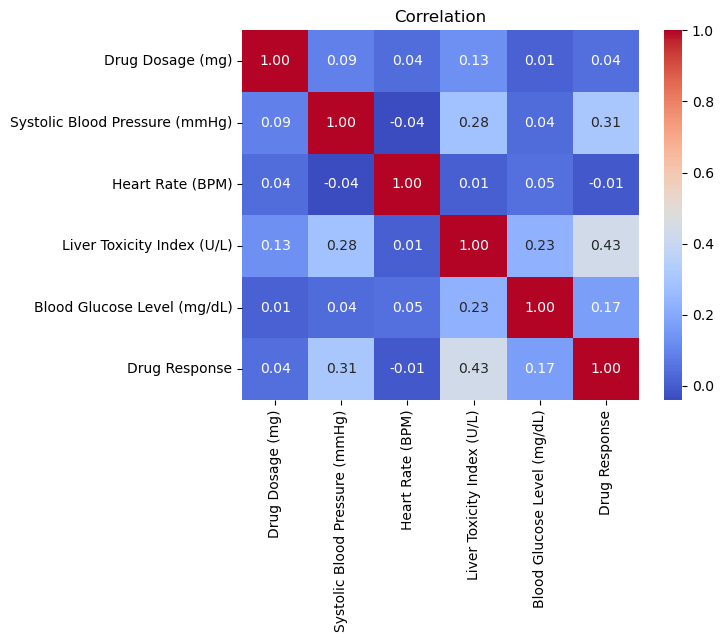

In [2]:
print(df.info())
print("Missing:", df.isnull().sum().sum(), "| Duplicates:", df.duplicated().sum())
display(df.describe().T)

df.hist(figsize=(10,6), bins=20); plt.tight_layout(); plt.show()
sns.countplot(data=df, x="Drug Response"); plt.title("Class Distribution"); plt.show()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f"); plt.title("Correlation"); plt.show()


## 2. Preprocessing

In [3]:
X = df.drop(columns="Drug Response")
y = df["Drug Response"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(400, 5) (100, 5)


## 3. SVM + Kernel Comparison

In [4]:
results=[]
for k in ["linear","poly","rbf"]:
    m=make_pipeline(StandardScaler(), SVC(kernel=k, C=1))
    m.fit(X_train,y_train); p=m.predict(X_test)
    results.append([k,accuracy_score(y_test,p),precision_score(y_test,p),
                    recall_score(y_test,p),f1_score(y_test,p)])
display(pd.DataFrame(results,columns=["Kernel","Accuracy","Precision","Recall","F1"]))


,Kernel,Accuracy,Precision,Recall,F1
0,linear,0.72,0.760870,0.673077,0.714286
1,poly,0.65,0.666667,0.653846,0.660194
2,rbf,0.77,0.754386,0.826923,0.788991


## 4. Tuning + Final Evaluation

Best: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        48
           1       0.75      0.79      0.77        52

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100



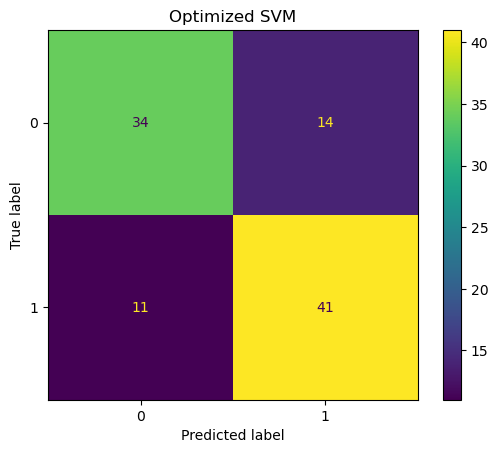

In [5]:
grid=GridSearchCV(
    make_pipeline(StandardScaler(),SVC()),
    {"svc__kernel":["linear","rbf","poly"],"svc__C":[.1,1,10],
     "svc__gamma":["scale","auto"]}, cv=5, scoring="f1"
)
grid.fit(X_train,y_train)
print("Best:", grid.best_params_)

p=grid.predict(X_test)
print(classification_report(y_test,p))
ConfusionMatrixDisplay.from_predictions(y_test,p)
plt.title("Optimized SVM"); plt.show()


## Conclusion
SVM was used to classify drug response. Standardization was applied, linear/poly/RBF kernels were compared, and GridSearchCV selected the best model. Accuracy, precision, recall and F1-score evaluate the final classifier.